MangoIV rows: 1980
Broccoli rows: 2160
Combined rows: 4140
['Negative' 'F30MangoIV-mScarlet' 'F30MangoIV-RiboJ-mScarlet'
 'tMangoIV-mScarlet' 'tMangoIV-RiboJ-mScarlet' 'F30-2xBroccoli-mScarlet'
 'F30-2xBroccoli-RiboJ-mScarlet' 'tdBroccoli-mScarlet'
 'tdBroccoli-RiboJ-mScarlet']


Failed to solve for group ('Broccoli', 'Negative', 'GFP-Gext', 'D3'): An upper bound is less than the corresponding lower bound.


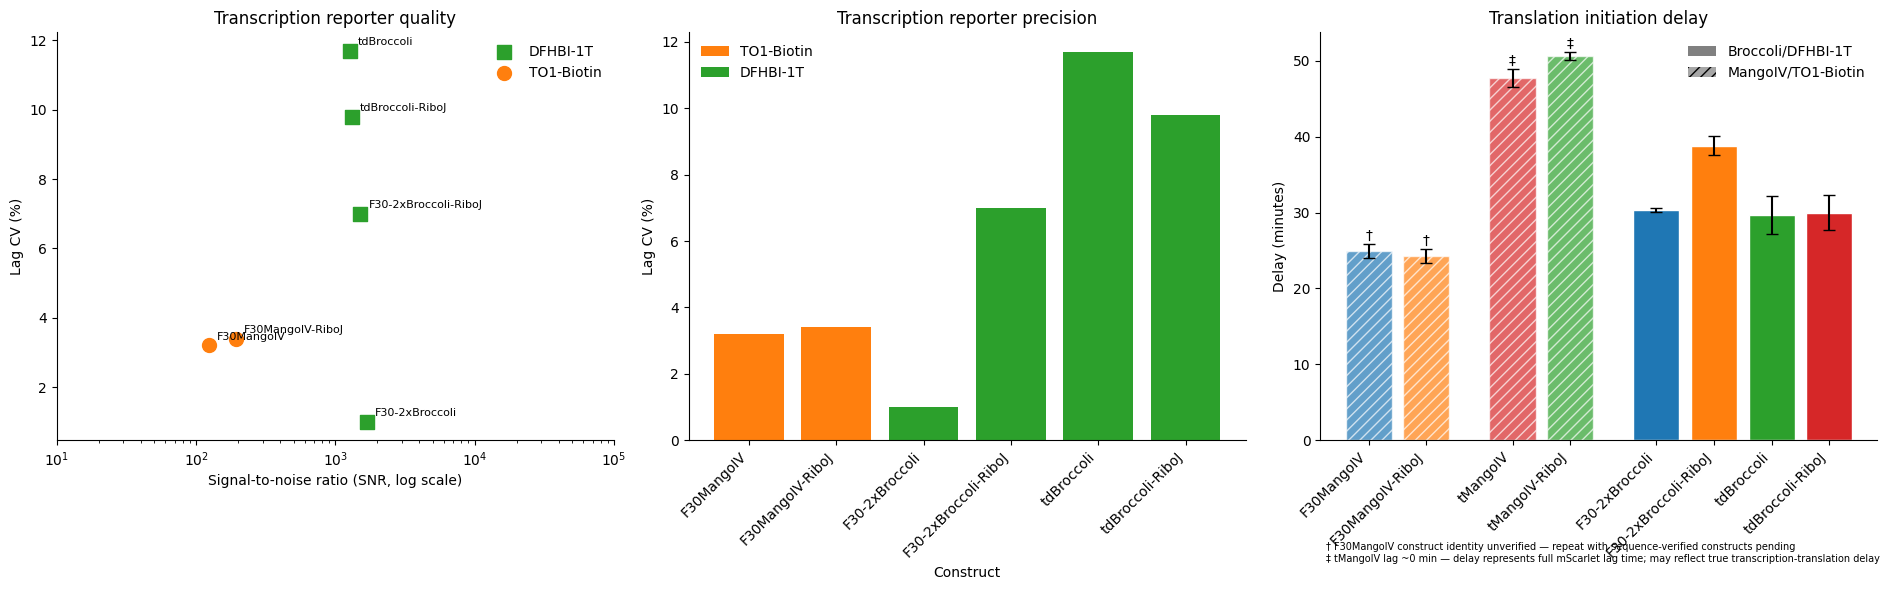

In [1]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
pr.plot_setup()

# Load background-subtracted data
mango_data = pd.read_csv("../20251030_Aptamer_test_Mango_mScarlet/20251030_MangoTO1_mScarlet_data_background_sbtrk.csv")
mango_data["Time"] = pd.to_timedelta(mango_data["Time"])
mango_data["Experiment"] = "MangoIV"

broccoli_data = pd.read_csv("../20251027_Aptamer_test_Broccoli_mScarlet/20251027_Broccoli_mScarlet_data_Background_Sbtrkt.csv")
broccoli_data["Time"] = pd.to_timedelta(broccoli_data["Time"])
broccoli_data["Experiment"] = "Broccoli"

combined = pd.concat([mango_data, broccoli_data], ignore_index=True)
combined["Time (hours)"] = combined["Time"].dt.total_seconds() / 3600

print(f"MangoIV rows: {len(mango_data)}")
print(f"Broccoli rows: {len(broccoli_data)}")
print(f"Combined rows: {len(combined)}")
print(combined["Name"].unique())

# Kinetics
# MangoIV TO1-Biotin — F30 only via per_well to avoid overflow
mango_TO1_kinetics = (
    combined[
        (combined["Experiment"] == "MangoIV") &
        (combined["Name"].str.contains("F30MangoIV")) &
        (combined["Read"] == "TO1-Biotin")
    ]
    .groupby(["Name", "Read", "Well"])
    .apply(pr.kinetic_analysis_per_well)
)

# tMangoIV TO1-Biotin separately
tmango_TO1_kinetics = (
    combined[
        (combined["Experiment"] == "MangoIV") &
        (combined["Name"].str.contains("tMangoIV")) &
        (combined["Read"] == "TO1-Biotin")
    ]
    .groupby(["Name", "Read", "Well"])
    .apply(pr.kinetic_analysis_per_well)
)

# MangoIV mScarlet
mango_mScarlet_kinetics = pr.kinetic_analysis(
    combined[
        (combined["Experiment"] == "MangoIV") &
        (combined["Name"] != "Negative") &
        (combined["Read"] == "mScarlet")
    ],
    group_by=["Name", "Read", "Well"]
)

# Broccoli aptamer
broccoli_aptamer_kinetics = pr.kinetic_analysis(
    combined[
        (combined["Experiment"] == "Broccoli") &
        (combined["Name"] != "Negative") &
        (combined["Read"] == "GFP-Gext")
    ],
    group_by=["Name", "Read", "Well"]
)

# Broccoli mScarlet
broccoli_mScarlet_kinetics = pr.kinetic_analysis(
    combined[
        (combined["Experiment"] == "Broccoli") &
        (combined["Name"] != "Negative") &
        (combined["Read"] == "mScarlet")
    ],
    group_by=["Name", "Read", "Well"]
)

# Extract lag times
mango_TO1_lag = mango_TO1_kinetics["Lag"]["Time"].dt.total_seconds() / 60
tmango_TO1_lag = tmango_TO1_kinetics["Lag"]["Time"].dt.total_seconds() / 60
tmango_TO1_lag = tmango_TO1_lag.clip(lower=0)
mango_mScarlet_lag = mango_mScarlet_kinetics["Lag"]["Time"].dt.total_seconds() / 60
broccoli_aptamer_lag = broccoli_aptamer_kinetics["Lag"]["Time"].dt.total_seconds() / 60
broccoli_mScarlet_lag = broccoli_mScarlet_kinetics["Lag"]["Time"].dt.total_seconds() / 60

# Means and stds
mango_TO1_mean = mango_TO1_lag.groupby("Name").mean()
mango_TO1_std = mango_TO1_lag.groupby("Name").std()
tmango_TO1_mean = tmango_TO1_lag.groupby("Name").mean()
tmango_TO1_std = tmango_TO1_lag.groupby("Name").std()
mango_mScarlet_mean = mango_mScarlet_lag.groupby("Name").mean()
mango_mScarlet_std = mango_mScarlet_lag.groupby("Name").std()
broccoli_aptamer_mean = broccoli_aptamer_lag.groupby("Name").mean()
broccoli_aptamer_std = broccoli_aptamer_lag.groupby("Name").std()
broccoli_mScarlet_mean = broccoli_mScarlet_lag.groupby("Name").mean()
broccoli_mScarlet_std = broccoli_mScarlet_lag.groupby("Name").std()

# Combine all TO1 lag times
all_TO1_mean = pd.concat([mango_TO1_mean, tmango_TO1_mean])
all_TO1_std = pd.concat([mango_TO1_std, tmango_TO1_std])

# SNR
steady_state_combined = pr.find_steady_state(combined, group_by=["Experiment", "Name", "Read", "Well"])
noise = combined[combined["Name"] == "Negative"].groupby(["Experiment", "Read"])["Data"].std().groupby(["Experiment", "Read"]).mean()
ss_data = steady_state_combined["Data_steadystate"]
signal = ss_data.groupby(["Experiment", "Name", "Read"]).mean().drop("Negative", level="Name")
snr = signal / noise
snr = snr.drop("Negative", level="Name", errors="ignore")

# Translation initiation delay
mango_delay_mean = mango_mScarlet_mean - mango_TO1_mean
mango_delay_std = (mango_mScarlet_std**2 + mango_TO1_std**2)**0.5
tmango_delay_mean = mango_mScarlet_mean.loc[mango_mScarlet_mean.index.str.contains("tMangoIV")] - tmango_TO1_mean
tmango_delay_std = (mango_mScarlet_std.loc[mango_mScarlet_std.index.str.contains("tMangoIV")]**2 + tmango_TO1_std**2)**0.5
broccoli_delay_mean = broccoli_mScarlet_mean - broccoli_aptamer_mean
broccoli_delay_std = (broccoli_mScarlet_std**2 + broccoli_aptamer_std**2)**0.5

# Lag CV for qc_df
mango_lag_cv = (mango_TO1_std / mango_TO1_mean * 100).round(1)
broccoli_aptamer_cv = (broccoli_aptamer_std / broccoli_aptamer_mean * 100).round(1)

# Build qc_df — F30 constructs only for panels 1 and 2
# (tMangoIV excluded from CV comparison as lag ~0 inflates CV artificially)
f30_mango_constructs = ["F30MangoIV-mScarlet", "F30MangoIV-RiboJ-mScarlet"]
broccoli_constructs_list = [
    "F30-2xBroccoli-mScarlet",
    "F30-2xBroccoli-RiboJ-mScarlet",
    "tdBroccoli-mScarlet",
    "tdBroccoli-RiboJ-mScarlet",
]

qc_df = pd.DataFrame({
    "Construct": [c.replace("-mScarlet", "") for c in f30_mango_constructs + broccoli_constructs_list],
    "Reporter": ["TO1-Biotin"] * len(f30_mango_constructs) + ["DFHBI-1T"] * len(broccoli_constructs_list),
    "SNR": [snr.loc[("MangoIV", c, "TO1-Biotin")] for c in f30_mango_constructs] +
           [snr.loc[("Broccoli", c, "GFP-Gext")] for c in broccoli_constructs_list],
    "Lag CV (%)": [round(mango_TO1_std.get(c, 0) / mango_TO1_mean.get(c, 1) * 100, 1) for c in f30_mango_constructs] +
                  [round(broccoli_aptamer_std.get(c, 0) / broccoli_aptamer_mean.get(c, 1) * 100, 1) for c in broccoli_constructs_list],
})

# Build delay_df — all constructs including tMangoIV
all_delay_data = []

for construct in f30_mango_constructs:
    clean = construct.replace("-mScarlet", "")
    all_delay_data.append({
        "Construct": clean,
        "Delay (minutes)": mango_delay_mean.get(construct, float("nan")),
        "Std": mango_delay_std.get(construct, float("nan")),
        "Experiment": "MangoIV",
        "Note": "†"
    })

for construct in ["tMangoIV-mScarlet", "tMangoIV-RiboJ-mScarlet"]:
    clean = construct.replace("-mScarlet", "")
    all_delay_data.append({
        "Construct": clean,
        "Delay (minutes)": tmango_delay_mean.get(construct, float("nan")),
        "Std": tmango_delay_std.get(construct, float("nan")),
        "Experiment": "MangoIV",
        "Note": "‡"
    })

for construct in broccoli_constructs_list:
    clean = construct.replace("-mScarlet", "")
    all_delay_data.append({
        "Construct": clean,
        "Delay (minutes)": broccoli_delay_mean.get(construct, float("nan")),
        "Std": broccoli_delay_std.get(construct, float("nan")),
        "Experiment": "Broccoli",
        "Note": ""
    })

delay_df = pd.DataFrame(all_delay_data).dropna(subset=["Delay (minutes)"])

# Reorder constructs
construct_order_qc = [
    "F30MangoIV", "F30MangoIV-RiboJ",
    "F30-2xBroccoli", "F30-2xBroccoli-RiboJ",
    "tdBroccoli", "tdBroccoli-RiboJ"
]
qc_df["Construct"] = pd.Categorical(qc_df["Construct"], categories=construct_order_qc, ordered=True)
qc_df = qc_df.sort_values("Construct").reset_index(drop=True)

construct_order_delay = [
    "F30MangoIV", "F30MangoIV-RiboJ",
    "tMangoIV", "tMangoIV-RiboJ",
    "F30-2xBroccoli", "F30-2xBroccoli-RiboJ",
    "tdBroccoli", "tdBroccoli-RiboJ"
]
delay_df["Construct"] = pd.Categorical(delay_df["Construct"], categories=construct_order_delay, ordered=True)
delay_df = delay_df.sort_values("Construct").reset_index(drop=True)

# Colour schemes
palette = {"TO1-Biotin": "tab:orange", "DFHBI-1T": "tab:green"}
markers = {"TO1-Biotin": "o", "DFHBI-1T": "s"}

all_colours = {
    "F30MangoIV": "tab:blue",
    "F30MangoIV-RiboJ": "tab:orange",
    "tMangoIV": "tab:red",
    "tMangoIV-RiboJ": "tab:green",
    "F30-2xBroccoli": "tab:blue",
    "F30-2xBroccoli-RiboJ": "tab:orange",
    "tdBroccoli": "tab:green",
    "tdBroccoli-RiboJ": "tab:red",
}

# Three panel figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1 — SNR vs Lag CV scatter
for reporter, group in qc_df.groupby("Reporter"):
    axes[0].scatter(group["SNR"], group["Lag CV (%)"],
                   color=palette[reporter], marker=markers[reporter],
                   s=100, label=reporter, zorder=3)
    for _, row in group.iterrows():
        axes[0].annotate(row["Construct"],
                        (row["SNR"], row["Lag CV (%)"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xscale("log")
axes[0].set_xlim(10, 100000)
axes[0].set_xlabel("Signal-to-noise ratio (SNR, log scale)")
axes[0].set_ylabel("Lag CV (%)")
axes[0].set_title("Transcription reporter quality")
axes[0].legend(title=None, frameon=False)

# Panel 2 — Lag CV bar plot
colours_p2 = [palette["TO1-Biotin"] if r == "TO1-Biotin" else palette["DFHBI-1T"]
              for r in qc_df["Reporter"]]
axes[1].bar(range(len(qc_df)), qc_df["Lag CV (%)"], color=colours_p2)
axes[1].set_xticks(range(len(qc_df)))
axes[1].set_xticklabels(qc_df["Construct"], rotation=45, ha="right")
axes[1].set_xlabel("Construct")
axes[1].set_ylabel("Lag CV (%)")
axes[1].set_title("Transcription reporter precision")
legend_elements_p2 = [
    Patch(facecolor="tab:orange", label="TO1-Biotin"),
    Patch(facecolor="tab:green", label="DFHBI-1T"),
]
axes[1].legend(handles=legend_elements_p2, frameon=False)

# Panel 3 — Translation initiation delay
x_positions = [0, 1, 2.5, 3.5, 5, 6, 7, 8]
for idx, (_, row) in enumerate(delay_df.iterrows()):
    hatch = "///" if row["Experiment"] == "MangoIV" else ""
    bar = axes[2].bar(x_positions[idx], row["Delay (minutes)"],
                color=all_colours.get(row["Construct"], "grey"),
                hatch=hatch, alpha=0.7 if hatch else 1.0,
                yerr=row["Std"], capsize=4, edgecolor="white", width=0.8)
    if row["Note"]:
        axes[2].annotate(row["Note"],
                        (x_positions[idx], row["Delay (minutes)"] + row["Std"] + 0.5),
                        ha="center", fontsize=10)

axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(delay_df["Construct"], rotation=45, ha="right")
axes[2].set_ylabel("Delay (minutes)")
axes[2].set_title("Translation initiation delay")
legend_elements_p3 = [
    Patch(facecolor="grey", label="Broccoli/DFHBI-1T"),
    Patch(facecolor="grey", hatch="///", alpha=0.7, label="MangoIV/TO1-Biotin")
]
axes[2].legend(handles=legend_elements_p3, frameon=False)
axes[2].text(0.01, -0.25,
    "† F30MangoIV construct identity unverified — repeat with sequence-verified constructs pending\n"
    "‡ tMangoIV lag ~0 min — delay represents full mScarlet lag time; may reflect true transcription-translation delay",
    transform=axes[2].transAxes, fontsize=7, va="top")

sns.despine()
plt.tight_layout()
#plt.savefig("./figures/summary_figure.png", dpi=600, bbox_inches="tight")
plt.show()